# Lab 3 — Descriptive Statistics Assignment: Gym Membership Dataset

**School of Computer Science and Engineering (SOCSE) — RV University**

**Name:** Ayush V     
**Roll No.:** 1RUA25CSE0100     
**Section:** 'G'

---

## Instructions

- This is a follow-up to Lab 3 (descriptive statistics on the student survey dataset). The same
  concepts — central tendency, dispersion, distribution shape, and visualization — are applied here
  to a **new dataset** describing gym members, so you can practice choosing the right
  statistic rather than remembering the answer from Lab 3.
-
- Every question below has an empty code cell (marked `# TODO`) for your solution, and most also   have a markdown cell marked **Your answer:** for a short written interpretation. Write your
  interpretation in your own words — a correct number with no explanation will not receive full  marks for questions that ask you to interpret.
- Run your notebook **top to bottom** (Kernel → Restart & Run All) before submitting, and make sure
  it completes with no errors.
-

### Learning objectives
By the end of this assignment you should be able to: compute and correctly choose between mean,
median, and mode; compute and interpret variance, standard deviation, and IQR; use skewness and
kurtosis to identify non-normal distributions; and build/interpret histograms, box plots, and scatter plots to support (or challenge) what the summary statistics suggest.

In [1]:
# --- Core libraries used throughout the notebook (provided — no changes needed) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.precision", 3)

print("Libraries loaded. Random seed set to", RANDOM_SEED)

Libraries loaded. Random seed set to 7


## Part 1 — The Dataset (provided, do not modify)

This dataset simulates **150 gym members**, with the same design idea as Lab 3: each numeric
feature is deliberately shaped differently, so no single statistic works well for all of them.

| Feature | Real-world meaning | Intended shape |
|---|---|---|
| `workout_duration_minutes` | Average length of a workout session | *(shape not disclosed — see Q7/Q8)* |
| `monthly_membership_fee_inr` | Monthly membership fee paid (₹) | *(shape not disclosed — see Q7/Q8)* |
| `attendance_percentage` | % of scheduled sessions actually attended | *(shape not disclosed — see Q7/Q8)* |
| `weekly_visit_count` | Number of gym visits per week | *(shape not disclosed — see Q7/Q8)* |
| `preferred_workout` | Favorite workout category | categorical |

Unlike Lab 3, the shapes are **not labeled** for you this time — figuring out which feature is
approximately normal, right-skewed, left-skewed, or bimodal (and *proving it* with statistics and
plots) is part of the assignment.

In [2]:
df=pd.read_csv("gym_members_synthetic.csv")
df.head(8)

,member_id,workout_duration_minutes,monthly_membership_fee_inr,attendance_percentage,weekly_visit_count,preferred_workout
0,M001,69.7,1690.0,71.7,1.3,Cardio
1,M002,81.0,2450.0,86.2,2.2,Weights
2,M003,62.6,2190.0,89.0,5.1,CrossFit
3,M004,65.7,3170.0,79.6,5.4,Cardio
4,M005,49.3,1050.0,80.7,1.5,Weights
5,M006,39.1,1180.0,88.0,5.0,Weights
6,M007,52.3,800.0,81.3,2.1,Weights
7,M008,73.0,2630.0,82.3,5.5,Yoga


### Q1 (2 marks) — Initial exploration

In the code cell below: display the shape of `df`, the data type of each column (`.dtypes`), the
summary statistics of the numeric columns (`.describe()`), and check whether any values are
missing (`.isna().sum()`).

In [3]:
# TODO: Q1 — shape, dtypes, describe(), and missing-value check
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nSummary statistics:\n", df.describe())
print("\nMissing values:\n", df.isna().sum())

Shape: (150, 6)

Data types:
 member_id                         str
workout_duration_minutes      float64
monthly_membership_fee_inr    float64
attendance_percentage         float64
weekly_visit_count            float64
preferred_workout                 str
dtype: object

Summary statistics:
        workout_duration_minutes  monthly_membership_fee_inr  \
count                   150.000                     150.000   
mean                     54.618                    2283.067   
std                      11.397                     984.837   
min                      27.800                     800.000   
25%                      48.050                    1515.000   
50%                      54.350                    2030.000   
75%                      62.875                    2825.000   
max                      81.000                    6420.000   

       attendance_percentage  weekly_visit_count  
count                150.000             150.000  
mean                  84.210        

## Part 2 — Measures of Central Tendency

Recall from Lab 3: the **mean** uses every value and is efficient but outlier-sensitive; the
**median** only depends on the middle position and is robust to outliers; the **mode** is the most
frequent value and is most meaningful for categorical or discrete data.



In the code cell below, compute the **mean, median, and mode** of each of the four numeric features
in `FEATURES`, and separately the **mode** of `preferred_workout`. Present the four numeric results
as a single small table (a DataFrame is fine).

In [4]:
# TODO: Q2 — mean, median, mode for each numeric feature; mode of preferred_workout
FEATURES = ["workout_duration_minutes", "monthly_membership_fee_inr","attendance_percentage", "weekly_visit_count"]
central_tendency = pd.DataFrame({"mean": df[FEATURES].mean(), "median": df[FEATURES].median(), "mode": df[FEATURES].mode().iloc[0]})
print(central_tendency)
print("\nMost common preferred_workout:", df["preferred_workout"].mode()[0])

                                mean   median    mode
workout_duration_minutes      54.618    54.35    57.8
monthly_membership_fee_inr  2283.067  2030.00  1440.0
attendance_percentage         84.210    85.10    85.1
weekly_visit_count             3.337     2.40     2.3

Most common preferred_workout: Cardio


### Q3  — Written interpretation

Looking at your table from Q2: for which numeric feature(s) do the mean and median differ the most
(in relative, not absolute, terms)? What does that gap suggest about the shape of that feature's
distribution, and in which direction would you expect its tail to stretch? You have not plotted
anything yet — base your answer only on the numbers.

**Your answer:**

weekly_visit_count has the largest relative difference between the mean and median. The mean (3.337) is noticeable that its higher than the median (2.40), which means that the distribution is right-skewed. This means the distribution likely has longer tail toward higher 'weekly_visit_count', possibly because a group of very frequent gym members visits much more than typical members.

### Q4 (4 marks) — The outlier effect

Suppose one gym member signs up for a **founder's lifetime membership** and pays a one-time fee of
**₹80,000** that month. In the code cell below: make a **copy** of `df` (do not modify the original
`df`), add this one hypothetical value to `monthly_membership_fee_inr` in the copy, and print the
mean and median of that column **before and after** adding it.

Then, in the markdown cell below, explain in 2–3 sentences why the mean and median reacted
differently, referencing what you know about how each statistic is calculated.

In [5]:
# TODO: Q4 — add the ₹80,000 outlier to a COPY of df, compare mean/median before vs. after
df_outlier = df.copy()
mean_before = df_outlier["monthly_membership_fee_inr"].mean()
median_before = df_outlier["monthly_membership_fee_inr"].median()

df_outlier.loc[len(df_outlier), "monthly_membership_fee_inr"] = 80000
mean_after = df_outlier["monthly_membership_fee_inr"].mean()
median_after = df_outlier["monthly_membership_fee_inr"].median()

print("Before adding outlier:")
print("Mean:", mean_before)
print("Median:", median_before)
print("\nAfter adding outlier:")
print("Mean:", mean_after)
print("Median:", median_after)

Before adding outlier:
Mean: 2283.0666666666666
Median: 2030.0

After adding outlier:
Mean: 2797.748344370861
Median: 2030.0


**Your answer:**

The mean increases substantially after adding the ₹80,000 outlier because the mean uses the magnitude of every value in the dataset, whereas median changes very little because it depends mainly on middle position of the sorted data and is therefore much less affected by one extreme value.

## Part 3 — Measures of Dispersion

### Q5 (5 marks) — Manual calculation

Without using `.var()`, `.std()`, `np.var()`, or `np.std()`, calculate the **variance** and
**standard deviation** of `workout_duration_minutes` by hand, following the sample-variance formula:

$$
\text{variance} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}
\qquad\qquad
\text{standard deviation} = \sqrt{\text{variance}}
$$

Work through it step by step (compute the mean, then the deviations, then the squared deviations,
then the variance, then the standard deviation — printing each intermediate result), and then
verify your manual answer matches `np.var(..., ddof=1)` and `np.std(..., ddof=1)`.

In [6]:
# TODO: Q5 — manual variance & standard deviation for workout_duration_minutes, then verify
x = df["workout_duration_minutes"]
n = len(x)
mean = sum(x) / n
deviations = x - mean
squared_deviations = deviations ** 2

variance = sum(squared_deviations) / (n - 1)
std = np.sqrt(variance)

print("Mean =", mean)
print("Variance =", variance)
print("Standard Deviation =", std)

print("\nVerification:")
print("NumPy Variance =", np.var(x, ddof=1))
print("NumPy Standard Deviation =", np.std(x, ddof=1))

Mean = 54.618
Variance = 129.89786174496643
Standard Deviation = 11.397274312087362

Verification:
NumPy Variance = 129.89786174496643
NumPy Standard Deviation = 11.397274312087362


### Q6 — IQR and outlier detection

For **each** of the four numeric features: compute Q1, Q3, and the IQR; compute the lower bound
(`Q1 - 1.5*IQR`) and upper bound (`Q3 + 1.5*IQR`); and count how many values fall outside those
bounds (i.e., how many outliers each feature has by this rule).

**Your answer (2–3 sentences):** Which feature has the most outliers by this rule? Suggest one
real-world reason a gym dataset might realistically show that pattern for that feature.

_(write here)_

In [7]:
# TODO: Q6 — Q1, Q3, IQR, bounds, and outlier count for each of the four numeric features
for feature in FEATURES:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[feature] < lower) | (df[feature] > upper)).sum()
    
    print(f"\n{feature}")
    print("Q1 =", Q1)
    print("Q3 =", Q3)
    print("IQR =", IQR)
    print("Lower Bound =", lower)
    print("Upper Bound =", upper)
    print("Number of Outliers =", outliers)


workout_duration_minutes
Q1 = 48.05
Q3 = 62.875
IQR = 14.825000000000003
Lower Bound = 25.812499999999993
Upper Bound = 85.11250000000001
Number of Outliers = 0

monthly_membership_fee_inr
Q1 = 1515.0
Q3 = 2825.0
IQR = 1310.0
Lower Bound = -450.0
Upper Bound = 4790.0
Number of Outliers = 2

attendance_percentage
Q1 = 80.175
Q3 = 88.775
IQR = 8.600000000000009
Lower Bound = 67.27499999999998
Upper Bound = 101.67500000000001
Number of Outliers = 1

weekly_visit_count
Q1 = 1.8
Q3 = 5.3
IQR = 3.5
Lower Bound = -3.45
Upper Bound = 10.55
Number of Outliers = 0


## Part 4 — Measures of Distribution Shape

### Q7 Compute the **skewness** and **excess kurtosis** of each of the four numeric features (use
`scipy.stats.skew` and `scipy.stats.kurtosis(..., fisher=True)`, or the equivalent pandas
`.skew()` / `.kurt()` methods). Present the results as a table.

For each feature, classify it as **right-skewed**, **left-skewed**, or **approximately symmetric**
based on the skewness value, and note whether the kurtosis suggests heavier tails, lighter tails, or
roughly normal tails compared to a normal distribution.

In [8]:
# TODO: Q7 — skewness & excess kurtosis for each numeric feature, plus your classification
for feature in FEATURES:
    skewness = df[feature].skew()
    kurtosis = df[feature].kurt()
    
    print(f"\n{feature}")
    print("Skewness =", skewness)
    print("Excess Kurtosis =", kurtosis)


workout_duration_minutes
Skewness = 0.08068201795955016
Excess Kurtosis = -0.15983106443430684

monthly_membership_fee_inr
Skewness = 1.1772101549712028
Excess Kurtosis = 1.8625786900738381

attendance_percentage
Skewness = -0.5611332828538445
Excess Kurtosis = -0.3239829081184542

weekly_visit_count
Skewness = 0.4455735755278103
Excess Kurtosis = -1.3749899629817852


### Q8 — Predict before you plot

Based only on the real-world meaning of each feature (not the numbers you've computed) — which of
the four features do you predict is **bimodal** (i.e., has two distinct groups of members rather
than one central tendency)? Explain your reasoning in 2–3 sentences, thinking about what kinds of
gym members might behave very differently from each other.

**Your answer:**

I predict that weekly_visit_count may be bimodal because gym members can naturally be divided into casual users who visit a few times per week and frequent users who visit regularly. These two groups could create two distinct peaks in the distribution.

## Part 5 — Data Visualizations

### Q9  — Histograms

Create a **2×2 grid of histograms** (one per numeric feature) with a KDE (density) curve overlaid
on each. On each subplot, draw a vertical line for the mean and a different-styled vertical line
for the median (with a legend), and give each subplot a clear title.

*Hint: `sns.histplot(..., kde=True, stat="density")` and `ax.axvline(...)` are useful here — see
Lab 3 for a similar example if you get stuck.*

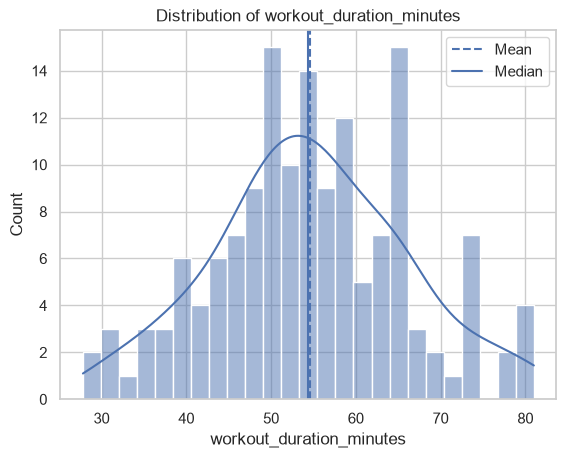

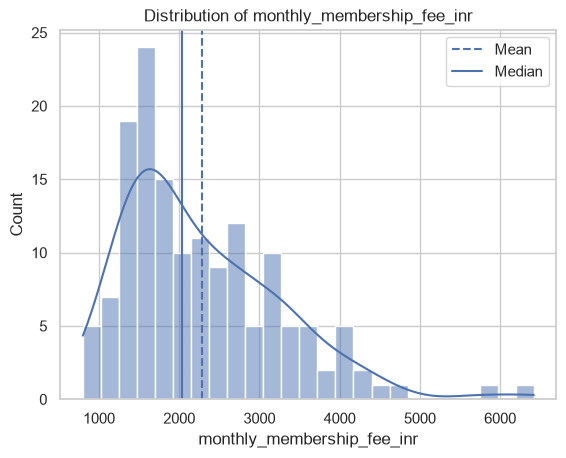

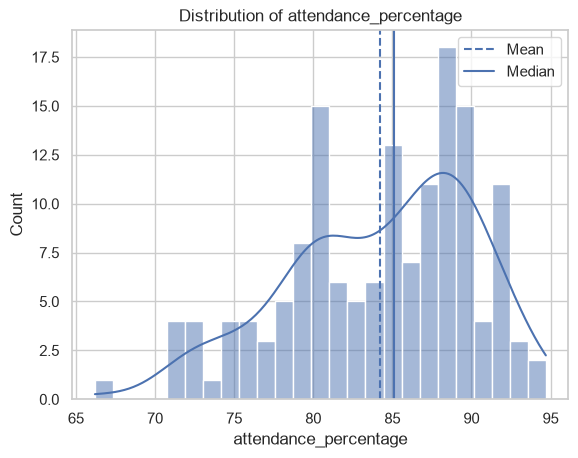

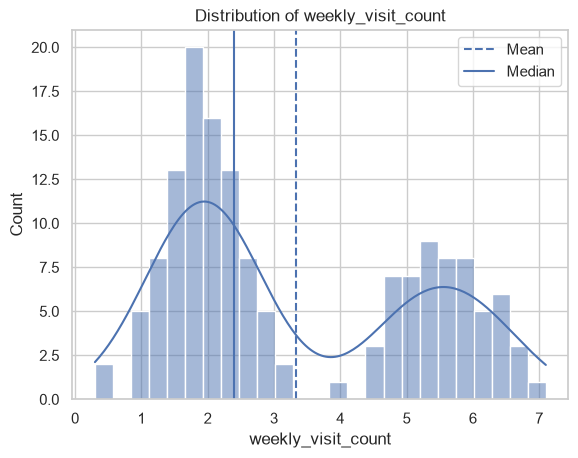

In [9]:
# TODO: Q9 — 2x2 histogram grid with KDE, mean line, and median line per feature
for feature in FEATURES:
    sns.histplot(data=df, x=feature, bins=25, kde=True)
    
    plt.axvline(df[feature].mean(), linestyle="--", label="Mean")
    plt.axvline(df[feature].median(), linestyle="-", label="Median")
    
    plt.title(f"Distribution of {feature}")
    plt.legend()
    plt.show()

### Q10 

Does the histogram for the feature you predicted in Q8 confirm or contradict your prediction?
If your prediction was wrong, which feature actually turned out to be bimodal, and does the mean
computed in Q2 fall in a sensible place on that histogram, or does it fall in an empty "valley"?

**Your answer:**

My prediction was correct because weekly_visit_count shows two distinct peaks in the histogram. The two peaks may represent different groups of gym members, such as casual and frequent visitors. The mean lies between the two peaks, near the valley of the distribution.

### Q11  — Box plots

Standardize (z-score) the four numeric features — `z = (x - mean) / std` — and plot all four as **box plots side by side** on one figure, so their spreads are visually comparable despite being ondifferent original scales (₹, minutes, %, visits). Label the y-axis clearly. Briefly note in the plot title or a code comment which feature(s) show visible outlier points.

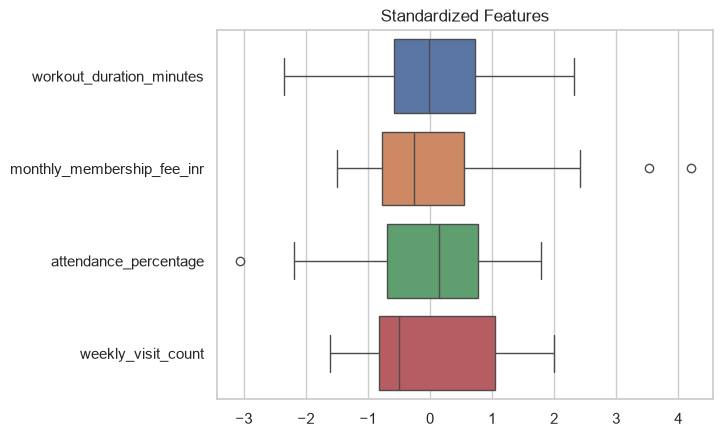

In [10]:
# Q11: Standardization

z_scores = (df[FEATURES] - df[FEATURES].mean()) / df[FEATURES].std()

sns.boxplot(data=z_scores, orient="h")
plt.title("Standardized Features")
plt.show()

### Q12 — Scatter plots

Choose **two pairs** of numeric features: one pair you hypothesize has a real relationship, and one
pair you hypothesize has little to no relationship. For each pair: compute the Pearson correlation
coefficient (`.corr()`), make a scatter plot, and put the correlation value in the plot title.

**Your answer (1–2 sentences per pair):** Did the scatter plots and correlation values support your
hypotheses? If a result surprised you, say so.

I expect attendance_percentage and weekly_visit_count to be related because members who visit the gym more frequently are likely to have higher attendance. I expect workout_duration_minutes and monthly_membership_fee_inr to be less related because the membership fee does not necessarily depend on how long a member works out.

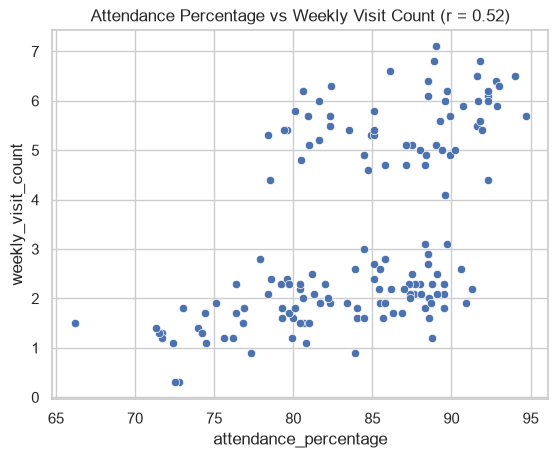

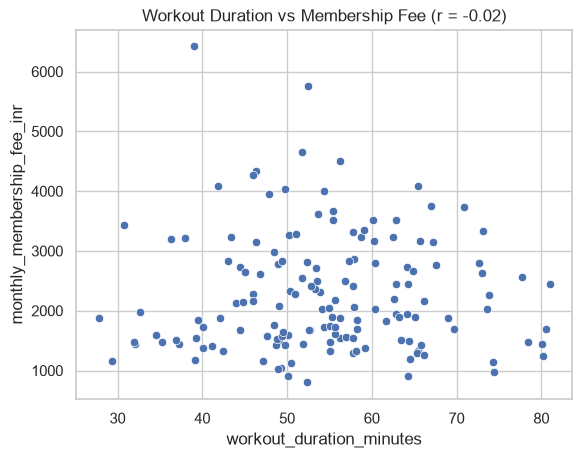

In [11]:
# TODO: Q12 — two scatter plots (one hypothesized relationship, one hypothesized no relationship)

r1 = df["attendance_percentage"].corr(df["weekly_visit_count"])
sns.scatterplot(data=df, x="attendance_percentage", y="weekly_visit_count")
plt.title(f"Attendance Percentage vs Weekly Visit Count (r = {r1:.2f})")
plt.show()

r2 = df["workout_duration_minutes"].corr(df["monthly_membership_fee_inr"])
sns.scatterplot(data=df, x="workout_duration_minutes", y="monthly_membership_fee_inr")
plt.title(f"Workout Duration vs Membership Fee (r = {r2:.2f})")
plt.show()

## Part 6 — Synthesis

### Q13 

Build **one summary table** with a row per numeric feature and columns for: mean, median, standard
deviation, IQR, skewness, and excess kurtosis (you have already computed all of these in Q2, Q5–Q7
— this question is about assembling them, not recomputing from scratch).

Then write a short paragraph (roughly 100–150 words) that, **for each of the four features**,
recommends which central-tendency measure (mean or median) and which dispersion measure (standard
deviation or IQR) should be reported, and briefly justifies the choice using the specific evidence
in your own table (not general rules quoted from Lab 3).

In [12]:
# TODO: Q13 — assemble the comparative summary table

summary = pd.DataFrame(index=FEATURES)

summary["Mean"] = df[FEATURES].mean()
summary["Median"] = df[FEATURES].median()
summary["Standard Deviation"] = df[FEATURES].std()
summary["IQR"] = df[FEATURES].quantile(0.75) - df[FEATURES].quantile(0.25)
summary["Skewness"] = df[FEATURES].skew()
summary["Excess Kurtosis"] = df[FEATURES].kurt()

summary

,Mean,Median,Standard Deviation,IQR,Skewness,Excess Kurtosis
workout_duration_minutes,54.618,54.35,11.397,14.825,0.081,-0.160
monthly_membership_fee_inr,2283.067,2030.00,984.837,1310.000,1.177,1.863
attendance_percentage,84.210,85.10,5.874,8.600,-0.561,-0.324
weekly_visit_count,3.337,2.40,1.886,3.500,0.446,-1.375


**Your answer (recommendation paragraph):**

For workout duration, the mean and median are almost same (54.618 and 54.35), and the skewness is very low at 0.081. So, the mean and standard deviation are good parameters to use. For monthly membership fee, the mean (2283.067) is higher than the median (2030), and the skewness is 1.177, showing that the data is right-skewed. Therefore, the median and IQR would be more suitable. For attendance percentage, the mean (84.210) and median (85.10) are fairly close, but the skewness of -0.561 shows some left-skewness, so the median and IQR would be safer. For weekly visit count, the mean (3.337) is higher than the median (2.40), with a skewness of 0.446. Thus the median and IQR would give a better idea of the typical value and spread

---

## Bonus (optional)

Group `df` by `preferred_workout` (`df.groupby("preferred_workout")`) and compare the mean
`attendance_percentage` across the four workout categories. Is attendance noticeably different for
any one category? Give one plausible real-world explanation for what you find (or for why there's
no real difference, if that's what you observe).

In [13]:
# TODO (bonus): groupby preferred_workout, compare mean attendance_percentage across categories

df.groupby("preferred_workout")["attendance_percentage"].mean()

preferred_workout
Cardio      83.558
CrossFit    82.325
Weights     85.526
Yoga        84.029
Name: attendance_percentage, dtype: float64

---

### Before you submit
- [ ] Ran the notebook top to bottom with no errors (Kernel → Restart & Run All)
- [ ] Every `# TODO` cell has working code, not just comments
- [ ] Every "Your answer" cell has a written response in your own words
- [ ] Did not modify the Part 1 dataset-generation code or the random seed